<h1>NOTEBOOK D'ENTRAINEMENT DES RESEAUX DE NEURONES POUR NOTRE CLASSIFIEUR A 5 CLASSES</h1>
<p>Pour mon travail de fin cycle de Licence à la faculté polytechnique de l'université de Kinshasa, je dois réaliser un système électronique de contrôle vocal d'un moteur DC. Il s'agit d'un problème IoT qui nécessite à la fois une analyse (et conception) logicielle et une analyse matérielle. Le côté matériel du projet comprends le moteur à courant continu que nous allons utiliser(un moteur à aimant permanent), le circuit à commander, la carte arduino nano 33 ble sense rev2 et le circuit de commande du moteur(un pont en H avec transistors). Quant au coté logiciel, c'est d'une part un modèle TinyML que nous devons concevoir de façon qu'elle en mesure de réconnaitre sept mots clés(go, up, down, left, stop, silence, unknown) à partir d'un enregistrement audio d'une seconde, et d'autre part, c'est aussi le code arduino qui utilise ce modèle pour commander le moteur DC.</p>

<p>La partie logicielle du projet est en grande partie inspirée de l'exemple "micro-speech" de tensorflow pour microcontrôleur qui nous a servi de base pour comprendre le fonctionnement de tensorflow sur Arduino. Notons que tensorflow est l'API que nous utilisons pour le Tiny Machine Learning.</p>

In [1]:
# Importons tous les modules que nous utiliserons
from tensorflow import keras # keras est un API qui permet de simplifier la création des réseaux de neurones
import os
import tensorflow as tf
import numpy as np # pour gérer les tenseurs
import verification_model as verification # Afin de mesurer la précision d'un modèle
import pretraitement.extraction_mfcc as extract # Pour extraire les "features" mfcc du spectrogramme
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder # Transformation des mots en nombre entier pour les NN
from pathlib import Path
from time import strftime

<h2>Chargement des données, prétraitement et répartition</h2>
<p>Dans cette partie, nous chargeons les données : des enregistrements audio d'une seconde</p>

In [2]:
# Chargement des données et prétraitement
DATASET = "data/" # Il s'agit du dossier ou chemin qui mène vers le dataset
MOTS_CLES = ("go", "up", "down", "left", "stop", "bed", "bird", "cat", "dog", "eight", "no", "forward", "nine", "off", "house") #
CLASSES = ("go", "up", "down", "left", "stop")

enregistrements, classes = [], []
print("CHARGEMENT DU DATASET...", flush=True)

for classe in CLASSES:
    dossier = os.path.join(DATASET, classe)
    compteur = 0
    for fichier in os.listdir(dossier):
        if not fichier.lower().endswith(".wav"):
            continue
        chemin = os.path.join(dossier, fichier)
        try:
            features = extract.extraction(chemin_fichier=chemin)
            enregistrements.append(features)
            classes.append(classe)
            compteur+=1
        except Exception as e:
            print(f"[ERREUR] {fichier} : {e}")

    print(f"{classe:<10} : {compteur} fichiers chargés.")

DATA = np.array(enregistrements, dtype=np.float32) # Nous passons à un tableau numpy
print(f"\nDATASET chargé avec succès: shape={DATA.shape}, dtype={DATA.dtype}")

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(classes)

print(f"Ordre des classes : {list(label_encoder.classes_)}")


CHARGEMENT DU DATASET...
go         : 3880 fichiers chargés.
up         : 3723 fichiers chargés.
down       : 3917 fichiers chargés.
left       : 3801 fichiers chargés.
stop       : 3872 fichiers chargés.

DATASET chargé avec succès: shape=(19193, 49, 40, 1), dtype=float32
Ordre des classes : ['down', 'go', 'left', 'stop', 'up']


In [3]:
# Répartition des données dans le jeu d'entrainement, de validation et de test
print(f"Dimension d'une entrée du modèle : {DATA[0].shape}")

np.random.seed(42) # Reproductibilité de l'expérience

def melangeur(datas, labels):
    """Cette fonction mélange aléatoirement les données
    afin d'avoir un modèle généralisé.
    """
    new_datas, new_labels = [], []
    indexes = list(range(len(datas)))
    np.random.shuffle(indexes)
    for idx in indexes:
        new_datas.append(datas[idx])
        new_labels.append(labels[idx])

    return np.array(new_datas), np.array(new_labels)

DATA, y = melangeur(DATA, y)

RATIO_TEST = 0.10 # Pourcentage du jeu de données de test
RATIO_VALIDATION = 0.25 # Pourcentage du jeu de données de validation

nombre_datas_validation = int(RATIO_VALIDATION * len(DATA))
nombre_datas_test = int(RATIO_TEST * len(DATA))
nombre_data_train = len(DATA) - (nombre_datas_test + nombre_datas_validation)

X_train, y_train = DATA[:nombre_data_train], y[:nombre_data_train]
(X_test, y_test) = (DATA[nombre_data_train:nombre_datas_test + nombre_data_train],
                    y[nombre_data_train:nombre_datas_test + nombre_data_train])
(X_val, y_val) = (DATA[nombre_datas_test + nombre_data_train:],
                  y[nombre_datas_test + nombre_data_train:])

print(f"Entrainement : {X_train.shape}")
print(f"Validation   : {X_val.shape}")
print(f"Test         : {X_test.shape}")
print(f"\nLabels encodés (test) : {set(y_test)}")

Dimension d'une entrée du modèle : (49, 40, 1)
Entrainement : (12476, 49, 40, 1)
Validation   : (4798, 49, 40, 1)
Test         : (1919, 49, 40, 1)

Labels encodés (test) : {0, 1, 2, 3, 4}


<h2>Définitions des modèles</h2>

In [4]:
# Modèle séquentiel avec l'API Séquentielle
def model_sequentiel(nbre_neurones_par_couche_cachee:tuple, activation_hidden:str,
                     loss:str, optimiseur_name:keras.Optimizer):
    """

    :param nbre_neurones_par_couche_cachee: il s'agit d'un tuple des nombres des neurones
    :param activation_hidden: fonction d'activation des couches cachées
    :param loss: fonction de coût à utiliser durant l'entrainement
    :param optimiseur_name: un objet Optimizer pour l'optimisation
    :return:
    """
    model = keras.Sequential()
    normalisation = keras.layers.Normalization(input_shape=X_train.shape[1:])

    model.add(normalisation)
    model.add(keras.layers.Flatten())
    for i in range(len(nbre_neurones_par_couche_cachee)):
        # Les couches cachées ou denses
        model.add(keras.layers.Dense(nbre_neurones_par_couche_cachee[i], activation=activation_hidden))
    model.add(keras.layers.Dense(len(CLASSES), activation=keras.activations.sigmoid)) # Couche de sortie
    model.compile(
        loss=loss,
        optimizer=optimiseur_name,
        metrics=["accuracy", "loss"]
    )
    normalisation.adapt(X_train)
    model.summary()

    return model

# Modèle convolutional (CNN)
def model_convolution(input_shape=(49, 40, 1), nbre_classes:int=5):
    inputs = keras.Input(shape=input_shape)

    # 1. Première couche de convolution + Normalisation
    # On extrait 16 motifs élémentaires avec un filtre de 3x3
    x = keras.layers.Conv2D(16, kernel_size=(3, 3), activation="relu", padding="same")(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x) # Divise la résolution par 2
    x = keras.layers.Dropout(0.25)(x)

    # 2. Deuxième couche de convolution (plus profonde)
    # Si la cible est très contrainte en mémoire, on peut utiliser SeparableConv2D
    x = keras.layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same")(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x) # Divise la résolution par 2
    x = keras.layers.Dropout(0.25)(x)

    # 3. Transition vers la classification
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(64, activation="relu")(x)
    x = keras.layers.Dropout(0.5)(x)

    outputs = keras.layers.Dense(nbre_classes, activation="softmax")(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name="CNN_Audio")

    return model


# Modèle Deep and Wide avec l'API de sous-classement
class ModelWideDeep(keras.Model):
    """Modèle basé sur l'API de sous-classement"""
    def __init__(self, activation_hidden:str, nbre_neurones_par_couche_cachee:tuple, **kwargs):
        super().__init__(**kwargs)
        self.hidden_layers = {
            "norm_deep": keras.layers.Normalization(),
            "norm_wide": keras.layers.Normalization()
        }
        for i in range(len(nbre_neurones_par_couche_cachee)):
            self.hidden_layers[f"hidden{i}"] = keras.layers.Dense(nbre_neurones_par_couche_cachee[i],
                                                                  activation=activation_hidden)
        self.sortie = keras.layers.Dense(len(CLASSES), activation=keras.activations.sigmoid)

    def call(self, input_tensors):
        input_wide, input_deep = input_tensors

        norm_deep = self.hidden_layers["norm_deep"]
        norm_wide = self.hidden_layers["norm_wide"]
        flatten = keras.layers.Flatten()

        hidden = flatten(norm_deep(input_deep))
        for layer in self.hidden_layers.keys():
            if (layer == "norm_deep") or (layer == "norm_wide"):
                continue
            hidden = self.hidden_layers[layer](hidden)

        print(f"Shape hidden : {hidden.shape}")
        concatenate = keras.layers.concatenate([
            flatten(norm_wide(input_wide)),
            hidden
        ])
        output = self.sortie(concatenate)
        return output


<h2>Entrainement des modèles</h2>

In [5]:
# Les rappels
rappels = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
]

In [ ]:
# Entrainement modèle séquentiel
neurones_couches = (100, 100)
optimiseur = keras.optimizers.Adam(learning_rate=1e-3)

model1 = model_sequentiel(nbre_neurones_par_couche_cachee=neurones_couches,
                          activation_hidden="relu",
                          loss="sparse_categorical_crossentropy",
                          optimiseur_name=optimiseur)
history = model1.fit(X_train, y_train,
                     epochs=200,
                     batch_size=32,
                     validation_data=(X_val, y_val),
                     callbacks=rappels)

In [ ]:
# Courbes d'apprentissage du premier modèle
perte, val_perte = history.history["loss"], history.history["val_loss"]
precision, val_precision = history.history["accuracy"], history.history["val_accuracy"]
epochs = range(1, 1 + len(perte))

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
plt.title("Courbes d'apprentissage du modèle séquentiel")

ax1.plot(epochs, perte, label="loss")
ax1.plot(epochs, val_perte, label="val_loss")
ax1.legend()
ax1.grid()

ax2.plot(epochs, precision, label="Accuracy")
ax2.plot(epochs, val_precision, label="Val_Accuracy")
ax2.legend()
ax2.grid()

In [ ]:
# Entrainement modèle Deep and Wide
model2 = ModelWideDeep(activation_hidden="relu",
                       nbre_neurones_par_couche_cachee=(50, 50))
model2.compile(
    loss=keras.losses.SparseCategoricalCrossentropy,
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"]
)
model2.hidden_layers["norm_deep"].adapt(X_train)
model2.hidden_layers["norm_wide"].adapt(X_train)
model2.summary()

history = model2.fit(
    x=(X_train, X_train),
    y=(y_train,),
    epochs=200,
    batch_size=32,
    validation_data=(
        (X_val, X_val), (y_val,)
    ),
    callbacks=rappels
           )

In [ ]:
# Courbes d'apprentissage du modèle Deep and Wide
perte, val_perte = history.history["loss"], history.history["val_loss"]
precision, val_precision = history.history["accuracy"], history.history["val_accuracy"]
epochs = range(1, 1 + len(perte))

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
plt.title("Courbes d'apprentissage du modèle séquentiel")

ax1.plot(epochs, perte, label="loss")
ax1.plot(epochs, val_perte, label="val_loss")
ax1.legend()
ax1.grid()

ax2.plot(epochs, precision, label="Accuracy")
ax2.plot(epochs, val_precision, label="Val_Accuracy")
ax2.legend()
ax2.grid()

In [6]:
# Entrainement modèle CNN
def get_run_log_dir(log_dir="my_logs"):
    return Path(log_dir) / strftime("execution_%Y_%m_%d_%H_%M_%S")

# run_log_dir = get_run_log_dir()
# tensorboard_cb = tf.keras.callbacks.TensorBoard(run_log_dir, profile_batch=(50, 150))
# rappels.append(tensorboard_cb)

model3 = model_convolution()
model3.compile(
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
    optimizer=keras.optimizers.Adam(learning_rate=1e-3)
)
model3.summary()

history = model3.fit(
    x=X_train,
    y=y_train,
    epochs=30,
    batch_size=32,
    validation_data=(
        X_val, y_val
    ),
    callbacks=rappels
)

Model: "CNN_Audio"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 49, 40, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 49, 40, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 49, 40, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 20, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 20, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 20, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 20, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3840)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       245,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 251,141 (981.02 KB)

 Trainable params: 251,045 (980.64 KB)

 Non-trainable params: 96 (384.00 B)

Epoch 1/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 195s 467ms/step - accuracy: 0.4174 - loss: 1.3781 - val_accuracy: 0.5058 - val_loss: 1.2044
Epoch 2/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 124s 271ms/step - accuracy: 0.4941 - loss: 1.1665 - val_accuracy: 0.6584 - val_loss: 0.8930
Epoch 3/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 151s 295ms/step - accuracy: 0.5420 - loss: 1.0485 - val_accuracy: 0.7059 - val_loss: 0.7898
Epoch 4/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 91s 233ms/step - accuracy: 0.6012 - loss: 0.9331 - val_accuracy: 0.7626 - val_loss: 0.6533
Epoch 5/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 97s 249ms/step - accuracy: 0.6535 - loss: 0.8295 - val_accuracy: 0.7476 - val_loss: 0.6759
Epoch 6/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 98s 251ms/step - accuracy: 0.6930 - loss: 0.7653 - val_accuracy: 0.8268 - val_loss: 0.4985
Epoch 7/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 170s 320ms/step - accuracy: 0.7281 - loss: 0.6875 - val_accuracy: 0.7718 - val_loss: 0.6886
Epoch 8/30
390/390 ━━━━━━━━━━━━━━━━━━━━ 105s 224ms/step - accuracy: 0.7544 - lo

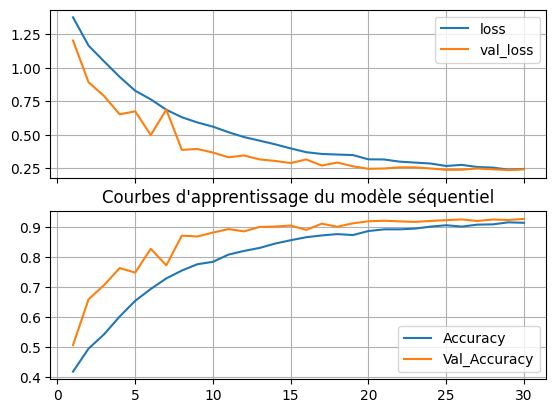

In [7]:
# Courbes d'apprentissage du modèle CNN
perte, val_perte = history.history["loss"], history.history["val_loss"]
precision, val_precision = history.history["accuracy"], history.history["val_accuracy"]
epochs = range(1, 1 + len(perte))

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
plt.title("Courbes d'apprentissage du modèle séquentiel")

ax1.plot(epochs, perte, label="loss")
ax1.plot(epochs, val_perte, label="val_loss")
ax1.legend()
ax1.grid()

ax2.plot(epochs, precision, label="Accuracy")
ax2.plot(epochs, val_precision, label="Val_Accuracy")
ax2.legend()
ax2.grid()

In [8]:
# Prédictions
y_predicted_proba = model3.predict(X_test)
y_predicted = [np.argmax(probas) for probas in y_predicted_proba]

60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step


In [9]:
# Matrice de confusion
matrice_confusion = tf.math.confusion_matrix(labels=y_test, predictions=y_predicted)
print(matrice_confusion)

tf.Tensor(
[[360  17   4   6  13]
 [ 14 335   2   0  19]
 [  3   7 370   0   5]
 [  6   4   6 345  17]
 [  5   5   4   2 370]], shape=(5, 5), dtype=int32)


In [11]:
# Sauvegarde du modèle non quantifié
converter = tf.lite.TFLiteConverter.from_keras_model(model3)
tflite_model = converter.convert()
open("./models/models_non_quantifies/commande_moteur_CNN1.tflite", "wb").write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\itel\AppData\Local\Temp\tmp_veyxb_8\assets


INFO:tensorflow:Assets written to: C:\Users\itel\AppData\Local\Temp\tmp_veyxb_8\assets


Saved artifact at 'C:\Users\itel\AppData\Local\Temp\tmp_veyxb_8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 49, 40, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  2241480688272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2241767307600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2241767307216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2241767306256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2241767305104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2241767305680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2241787135376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2241787138640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2241787138256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2241787138064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  22417673

1009756